# 02 — Exploratory Data Analysis

This notebook systematically explores all four raw datasets collected in
notebook 01. The goal is not to produce final results — it is to build
a deep understanding of the data before touching any model.

Every decision made in notebook 03 (feature engineering) and notebook 04
(modelling) traces back to a finding here. By the end of this notebook
we will know:

- The shape, trend, and seasonality of every time series
- Which series are stationary and which need differencing
- Which macroeconomic variables lead price and demand movements
- Where the data has gaps, outliers, or structural breaks
- Which lags to use as features in the machine learning models

**Notebooks must be run in order:**
`01_setup.ipynb` → `02_eda.ipynb` → `03_features.ipynb`

## 1. Imports and Configuration

In [1]:
import sys
import os

# Navigate from notebooks/ up to project root where config.py lives
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, project_root)
os.chdir(project_root)

print(f"Project root : {project_root}")
print(f"Working dir  : {os.getcwd()}")
print(f"config.py exists: {os.path.exists('config.py')}")

Project root : /Users/teguh/Jupyter Notebook/praharadata/Projects/chemical-forecasting
Working dir  : /Users/teguh/Jupyter Notebook/praharadata/Projects/chemical-forecasting
config.py exists: True


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")

from config import (
    RAW_FRED, RAW_WORLDBANK, RAW_EIA, RAW_M5,
    START_DATE, END_DATE, TEST_CUTOFF_DATE
)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.figsize":   (14, 4),
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})
COLORS = ["#2E75B6", "#E8593C", "#1D9E75", "#BA7517", "#7F77DD"]

print("Imports loaded successfully.")

Imports loaded successfully.


## 2. Load and Merge All Raw Data

We load all four raw datasets and align them on a common weekly date index.
This produces a single master DataFrame that all subsequent EDA sections
work from.

Alignment strategy:
- FRED and EIA are already weekly — load directly
- World Bank is monthly interpolated to weekly — load directly
- M5 demand covers a different period (2011–2016) — kept separate
- All series aligned on weekly Sunday frequency using outer join
- Missing values are NOT filled here — we want to see the true gaps first

In [3]:
# ── Load raw files ────────────────────────────────────────────────────────────
fred_df = pd.read_csv(RAW_FRED,      index_col="date", parse_dates=True)
wb_df   = pd.read_csv(RAW_WORLDBANK, index_col="date", parse_dates=True)
eia_df  = pd.read_csv(RAW_EIA,       index_col="date", parse_dates=True)
m5_df   = pd.read_csv(RAW_M5,        index_col="date", parse_dates=True)

# ── Merge FRED + World Bank + EIA on common weekly index ─────────────────────
master_df = (
    fred_df
    .join(wb_df,  how="outer", rsuffix="_wb")
    .join(eia_df, how="outer", rsuffix="_eia")
)
master_df = master_df.sort_index()
master_df = master_df.loc[START_DATE:END_DATE]

print("Master DataFrame (FRED + World Bank + EIA)")
print(f"  Shape  : {master_df.shape[0]} rows × {master_df.shape[1]} columns")
print(f"  Period : {master_df.index.min().date()} → {master_df.index.max().date()}")
print(f"\nColumns:")
for col in master_df.columns:
    n_null = master_df[col].isna().sum()
    pct    = n_null / len(master_df) * 100
    print(f"  {col:<35} {n_null:>5} nulls  ({pct:.1f}%)")

print(f"\nM5 Demand Series (separate period)")
print(f"  Shape  : {m5_df.shape[0]} rows × {m5_df.shape[1]} columns")
print(f"  Period : {m5_df.index.min().date()} → {m5_df.index.max().date()}")

Master DataFrame (FRED + World Bank + EIA)
  Shape  : 1305 rows × 16 columns
  Period : 2000-01-02 → 2024-12-29

Columns:
  crude_oil_wti                           1 nulls  (0.1%)
  natural_gas_henry_hub                   2 nulls  (0.2%)
  ppi_chemicals                        1005 nulls  (77.0%)
  ppi_plastics                         1005 nulls  (77.0%)
  industrial_production_idx            1005 nulls  (77.0%)
  capacity_utilisation                 1005 nulls  (77.0%)
  us_gdp                               1205 nulls  (92.3%)
  unemployment_rate                    1005 nulls  (77.0%)
  crude_oil_avg                          43 nulls  (3.3%)
  coal_australia                         43 nulls  (3.3%)
  natural_gas_us                         43 nulls  (3.3%)
  fertiliser_urea                        43 nulls  (3.3%)
  phosphate_rock                         43 nulls  (3.3%)
  crude_oil_stocks                        1 nulls  (0.1%)
  refinery_utilisation                    1 nulls  (0.1%)
  

## 3. Visual Inspection — Price Series

We plot every price-related time series to get an intuitive feel for
trend, volatility regimes, and obvious structural breaks before running
any statistical tests.

Key events to look for:
- **2008–2009**: Global financial crisis — sharp price collapses
- **2014–2016**: Oil price crash — crude fell from $110 to $30
- **2020 Q1**: COVID-19 demand shock — crude briefly went negative
- **2021–2022**: Post-COVID commodity supercycle and Ukraine war spike

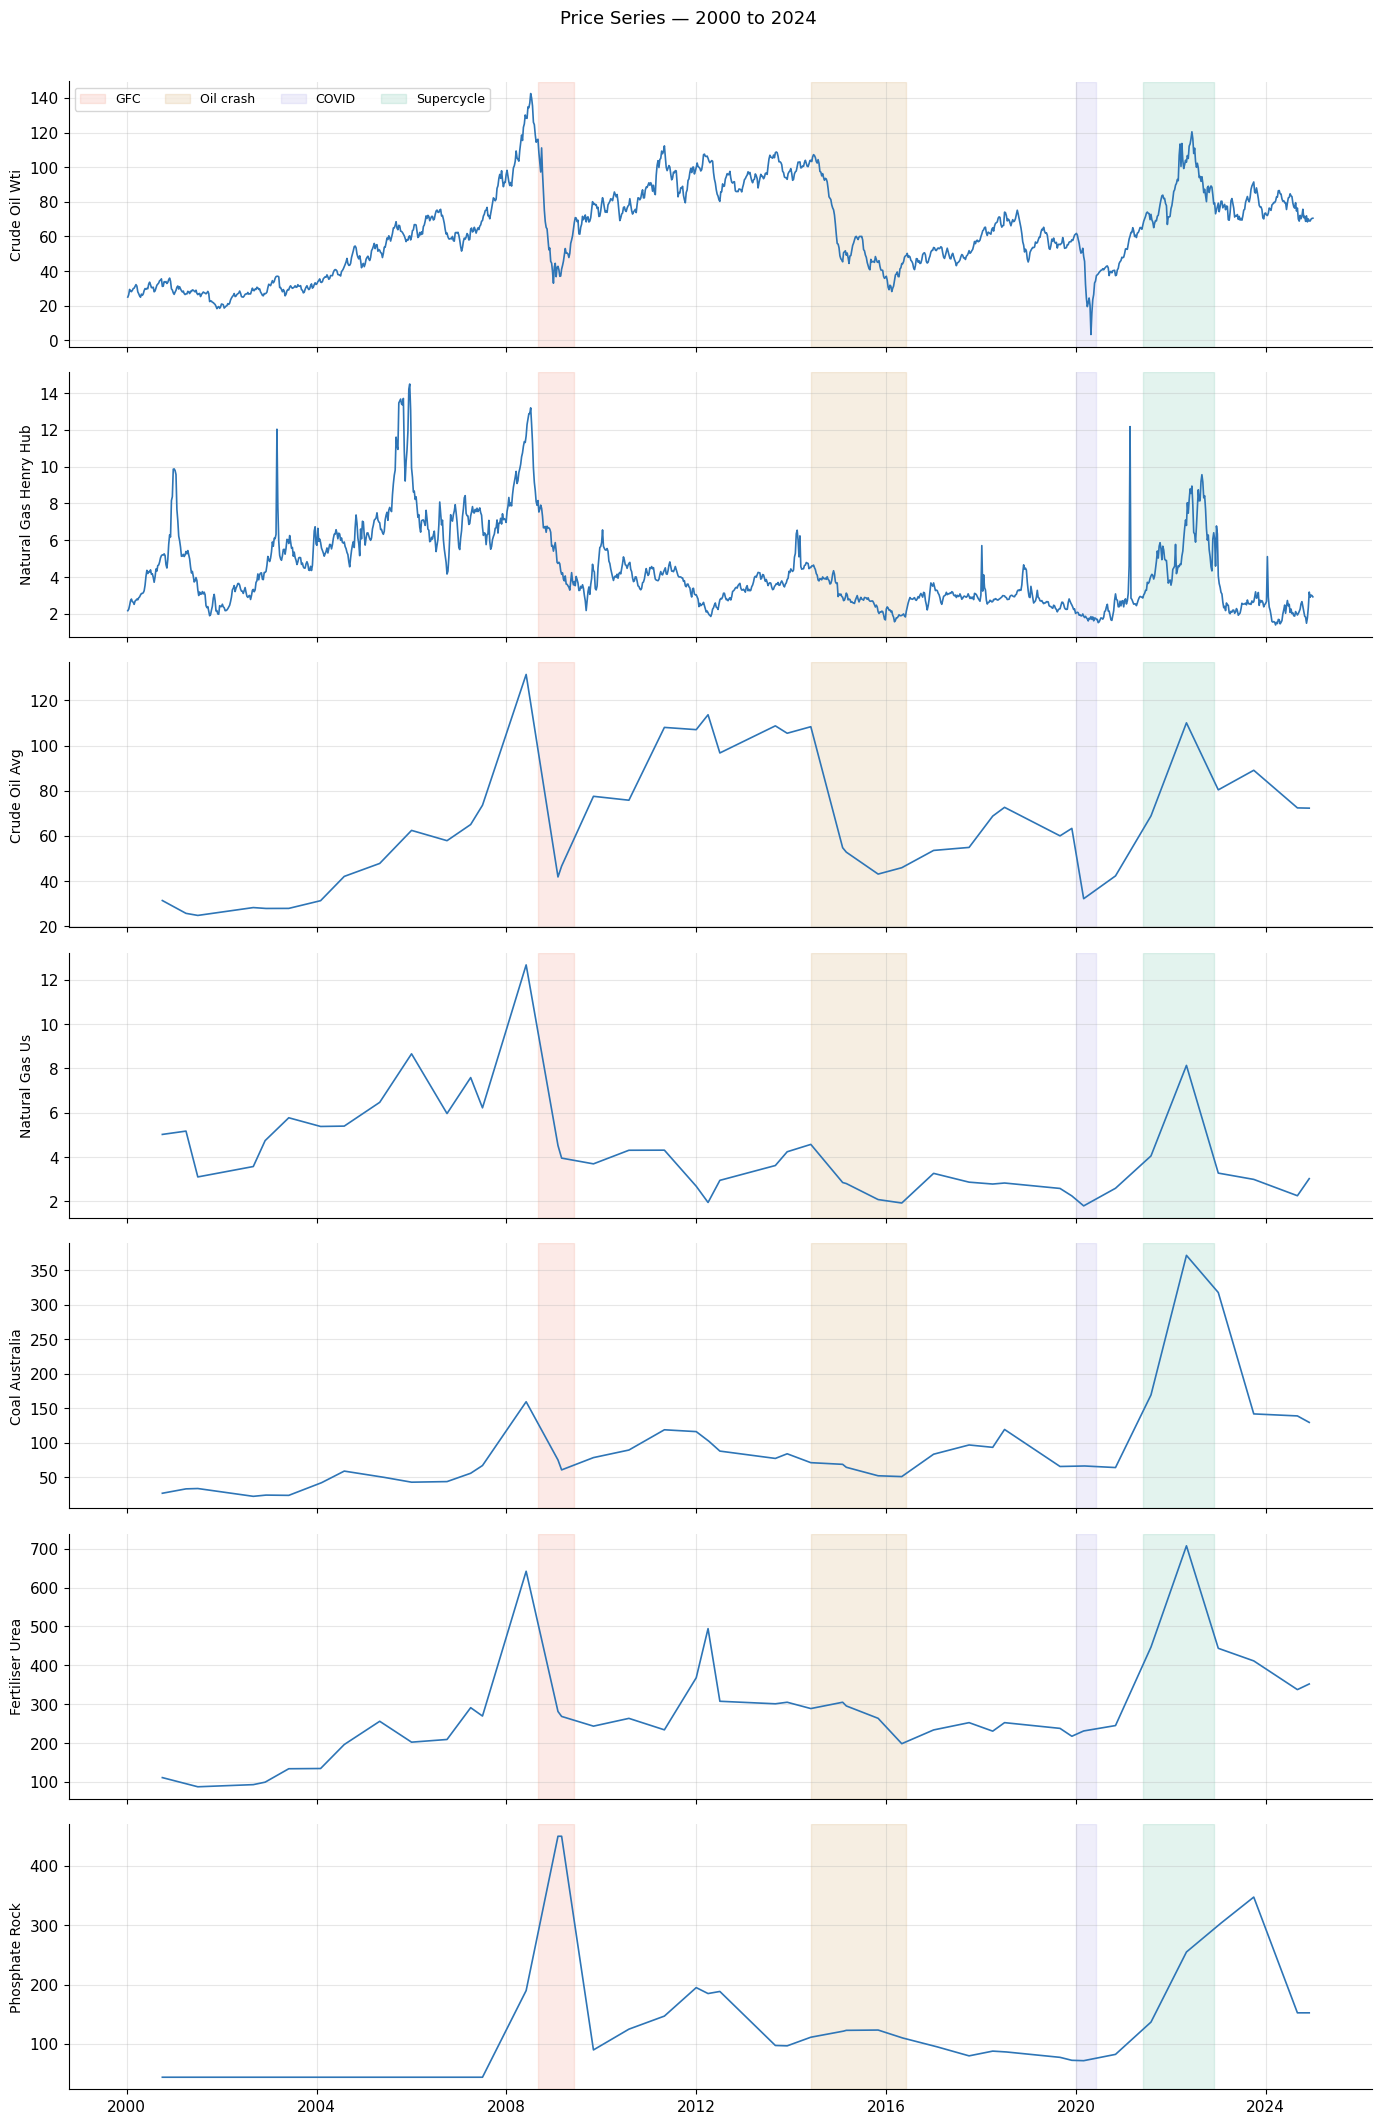

Saved → outputs/figures/01_price_series.png


In [4]:
PRICE_COLS = [
    "crude_oil_wti",
    "natural_gas_henry_hub",
    "crude_oil_avg",
    "natural_gas_us",
    "coal_australia",
    "fertiliser_urea",
    "phosphate_rock",
]

fig, axes = plt.subplots(len(PRICE_COLS), 1,
                         figsize=(14, 3 * len(PRICE_COLS)),
                         sharex=True)

for ax, col in zip(axes, PRICE_COLS):
    series = master_df[col].dropna()
    ax.plot(series.index, series.values, color=COLORS[0], linewidth=1.2)
    ax.set_ylabel(col.replace("_", " ").title(), fontsize=10)

    # Shade key event periods
    events = [
        ("2008-09", "2009-06", "#E8593C", "GFC"),
        ("2014-06", "2016-06", "#BA7517", "Oil crash"),
        ("2020-01", "2020-06", "#7F77DD", "COVID"),
        ("2021-06", "2022-12", "#1D9E75", "Supercycle"),
    ]
    for start, end, color, label in events:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.12, color=color, label=label)

axes[0].legend(loc="upper left", fontsize=9, ncol=4)
fig.suptitle("Price Series — 2000 to 2024", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("outputs/figures/01_price_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/figures/01_price_series.png")

## 4. Visual Inspection — Macro & Supply Series

We plot the macroeconomic indicators and EIA supply-side series.
These are the potential **leading indicators** — variables that may
move before prices change and therefore carry predictive signal.

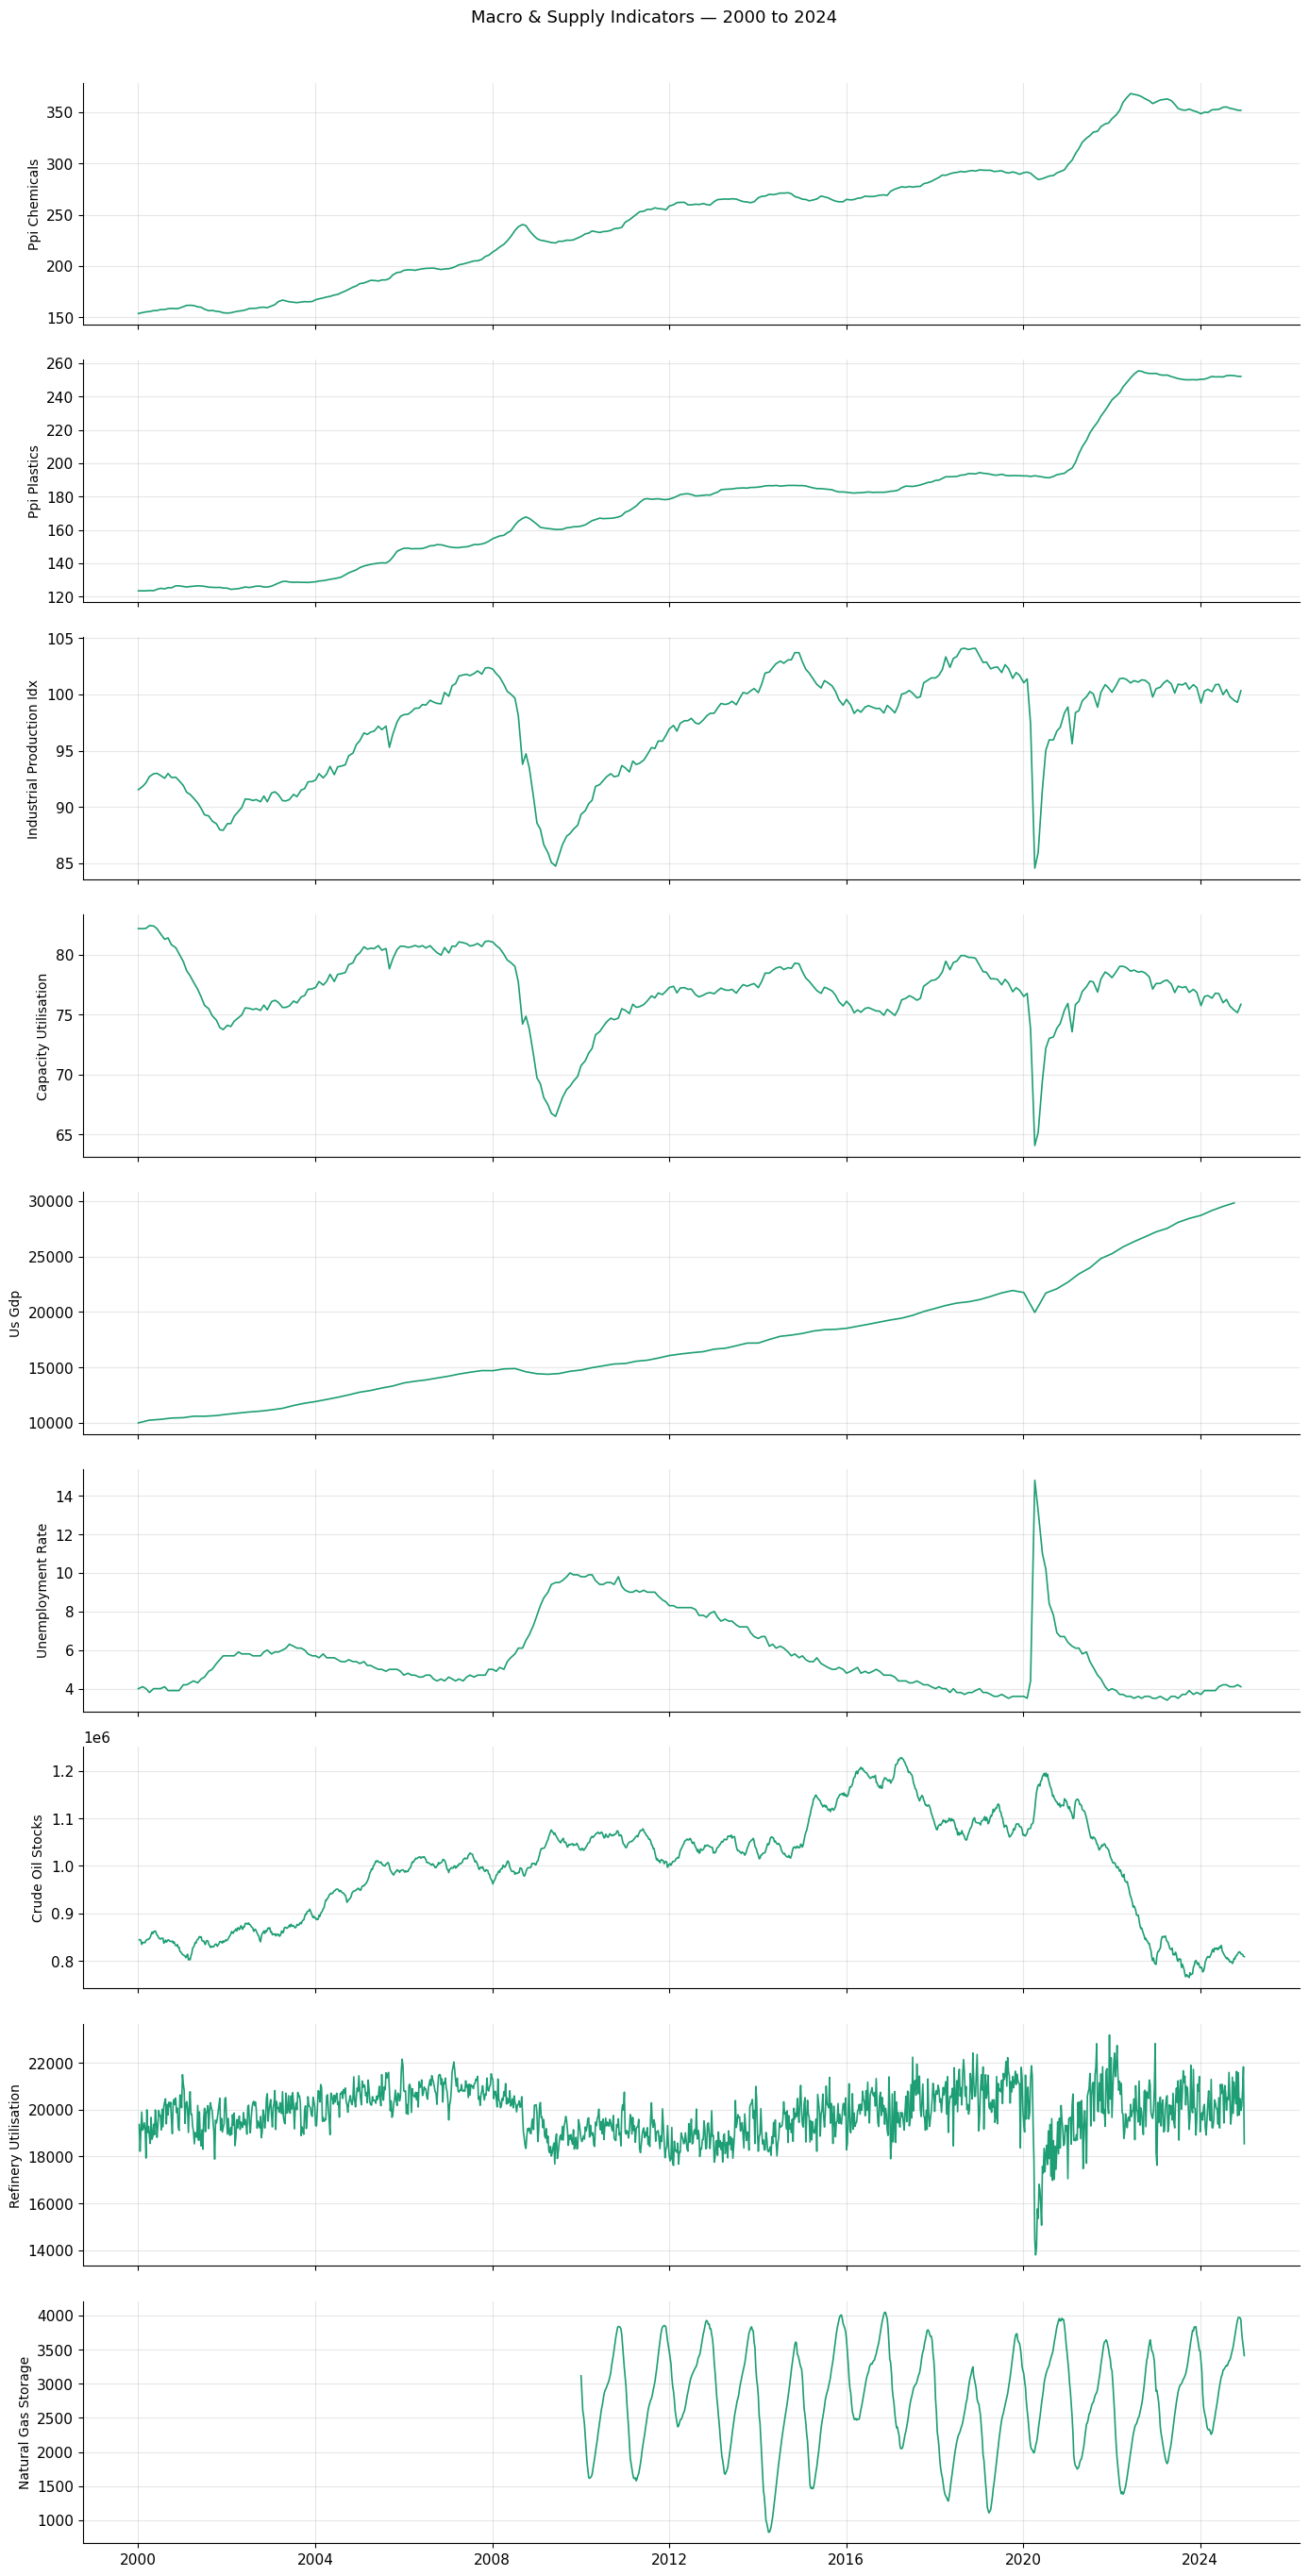

Saved → outputs/figures/02_macro_series.png


In [5]:
MACRO_COLS = [
    "ppi_chemicals",
    "ppi_plastics",
    "industrial_production_idx",
    "capacity_utilisation",
    "us_gdp",
    "unemployment_rate",
    "crude_oil_stocks",
    "refinery_utilisation",
    "natural_gas_storage",
]

fig, axes = plt.subplots(len(MACRO_COLS), 1,
                         figsize=(14, 3 * len(MACRO_COLS)),
                         sharex=True)

for ax, col in zip(axes, MACRO_COLS):
    series = master_df[col].dropna()
    ax.plot(series.index, series.values, color=COLORS[2], linewidth=1.2)
    ax.set_ylabel(col.replace("_", " ").title(), fontsize=10)

fig.suptitle("Macro & Supply Indicators — 2000 to 2024", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("outputs/figures/02_macro_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/figures/02_macro_series.png")

## 5. Visual Inspection — M5 Demand Series

The M5 weekly demand series covers January 2011 to May 2016.
We inspect the overall trend, seasonality pattern, and any
anomalies before using it as the demand forecasting benchmark.

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Raw series
axes[0].plot(m5_df.index, m5_df["total_sales"],
             color=COLORS[3], linewidth=1.2)
axes[0].set_title("M5 Weekly Total Demand (all products, all stores)")
axes[0].set_ylabel("Units sold")

# Year-over-year overlay
m5_df["year"]    = m5_df.index.year
m5_df["week_no"] = m5_df.index.isocalendar().week.astype(int)

for year, group in m5_df.groupby("year"):
    axes[1].plot(group["week_no"], group["total_sales"],
                 label=str(year), linewidth=1.2, alpha=0.8)

axes[1].set_title("Year-over-Year Seasonal Pattern")
axes[1].set_xlabel("Week of year")
axes[1].set_ylabel("Units sold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("outputs/figures/03_m5_demand.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/figures/03_m5_demand.png")

## 6. Stationarity Tests

Time series models require us to know whether each series is stationary
(constant mean and variance over time) or non-stationary (trending).

We run two complementary tests on every series:

**Augmented Dickey-Fuller (ADF)**
- H₀: the series has a unit root (non-stationary)
- Reject H₀ if p-value < 0.05 → series is stationary

**KPSS (Kwiatkowski–Phillips–Schmidt–Shin)**
- H₀: the series is stationary
- Reject H₀ if p-value < 0.05 → series is non-stationary

Using both together avoids the blind spots of each individual test.
A series is confirmed stationary only when ADF rejects H₀ AND KPSS
does not reject H₀.

In [8]:
def stationarity_tests(series, name):
    """Run ADF and KPSS tests on a series. Return result dict."""
    s = series.dropna()
    if len(s) < 20:
        return {"series": name, "n": len(s), "adf_p": None,
                "kpss_p": None, "verdict": "insufficient data"}

    # ADF test
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag="AIC")

    # KPSS test
    kpss_stat, kpss_p, _, _ = kpss(s, regression="c", nlags="auto")

    # Verdict
    adf_stationary  = adf_p  < 0.05
    kpss_stationary = kpss_p > 0.05

    if adf_stationary and kpss_stationary:
        verdict = "STATIONARY"
    elif not adf_stationary and not kpss_stationary:
        verdict = "NON-STATIONARY"
    else:
        verdict = "UNCERTAIN"

    return {
        "series":  name,
        "n":       len(s),
        "adf_p":   round(adf_p,  4),
        "kpss_p":  round(kpss_p, 4),
        "adf":     "stationary" if adf_stationary  else "unit root",
        "kpss":    "stationary" if kpss_stationary else "non-stationary",
        "verdict": verdict,
    }

ALL_SERIES = PRICE_COLS + MACRO_COLS

results = [stationarity_tests(master_df[col], col)
           for col in ALL_SERIES if col in master_df.columns]

results_df = pd.DataFrame(results)
print("Stationarity Test Results\n")
print(results_df[["series", "n", "adf_p", "kpss_p", "adf", "kpss", "verdict"]]
      .to_string(index=False))

results_df.to_csv("outputs/reports/stationarity_tests.csv", index=False)
print("\nSaved → outputs/reports/stationarity_tests.csv")

Stationarity Test Results

                   series    n  adf_p  kpss_p        adf           kpss        verdict
            crude_oil_wti 1304 0.0414  0.0100 stationary non-stationary      UNCERTAIN
    natural_gas_henry_hub 1303 0.0144  0.0100 stationary non-stationary      UNCERTAIN
            crude_oil_avg 1262 0.0248  0.0100 stationary non-stationary      UNCERTAIN
           natural_gas_us 1262 0.0105  0.0100 stationary non-stationary      UNCERTAIN
           coal_australia 1262 0.0081  0.0100 stationary non-stationary      UNCERTAIN
          fertiliser_urea 1262 0.0120  0.0100 stationary non-stationary      UNCERTAIN
           phosphate_rock 1262 0.0050  0.0100 stationary non-stationary      UNCERTAIN
            ppi_chemicals  300 0.9265  0.0100  unit root non-stationary NON-STATIONARY
             ppi_plastics  300 0.9663  0.0100  unit root non-stationary NON-STATIONARY
industrial_production_idx  300 0.2325  0.0100  unit root non-stationary NON-STATIONARY
     capacity_ut

## 7. Seasonality Decomposition

We apply STL (Seasonal-Trend decomposition using LOESS) to the two
primary target variables — WTI crude oil price and M5 demand — to
separate trend, seasonality, and residual components.

STL is preferred over classical decomposition because it handles
outliers robustly and works with any seasonal period. We use a
52-week seasonal period for weekly data.

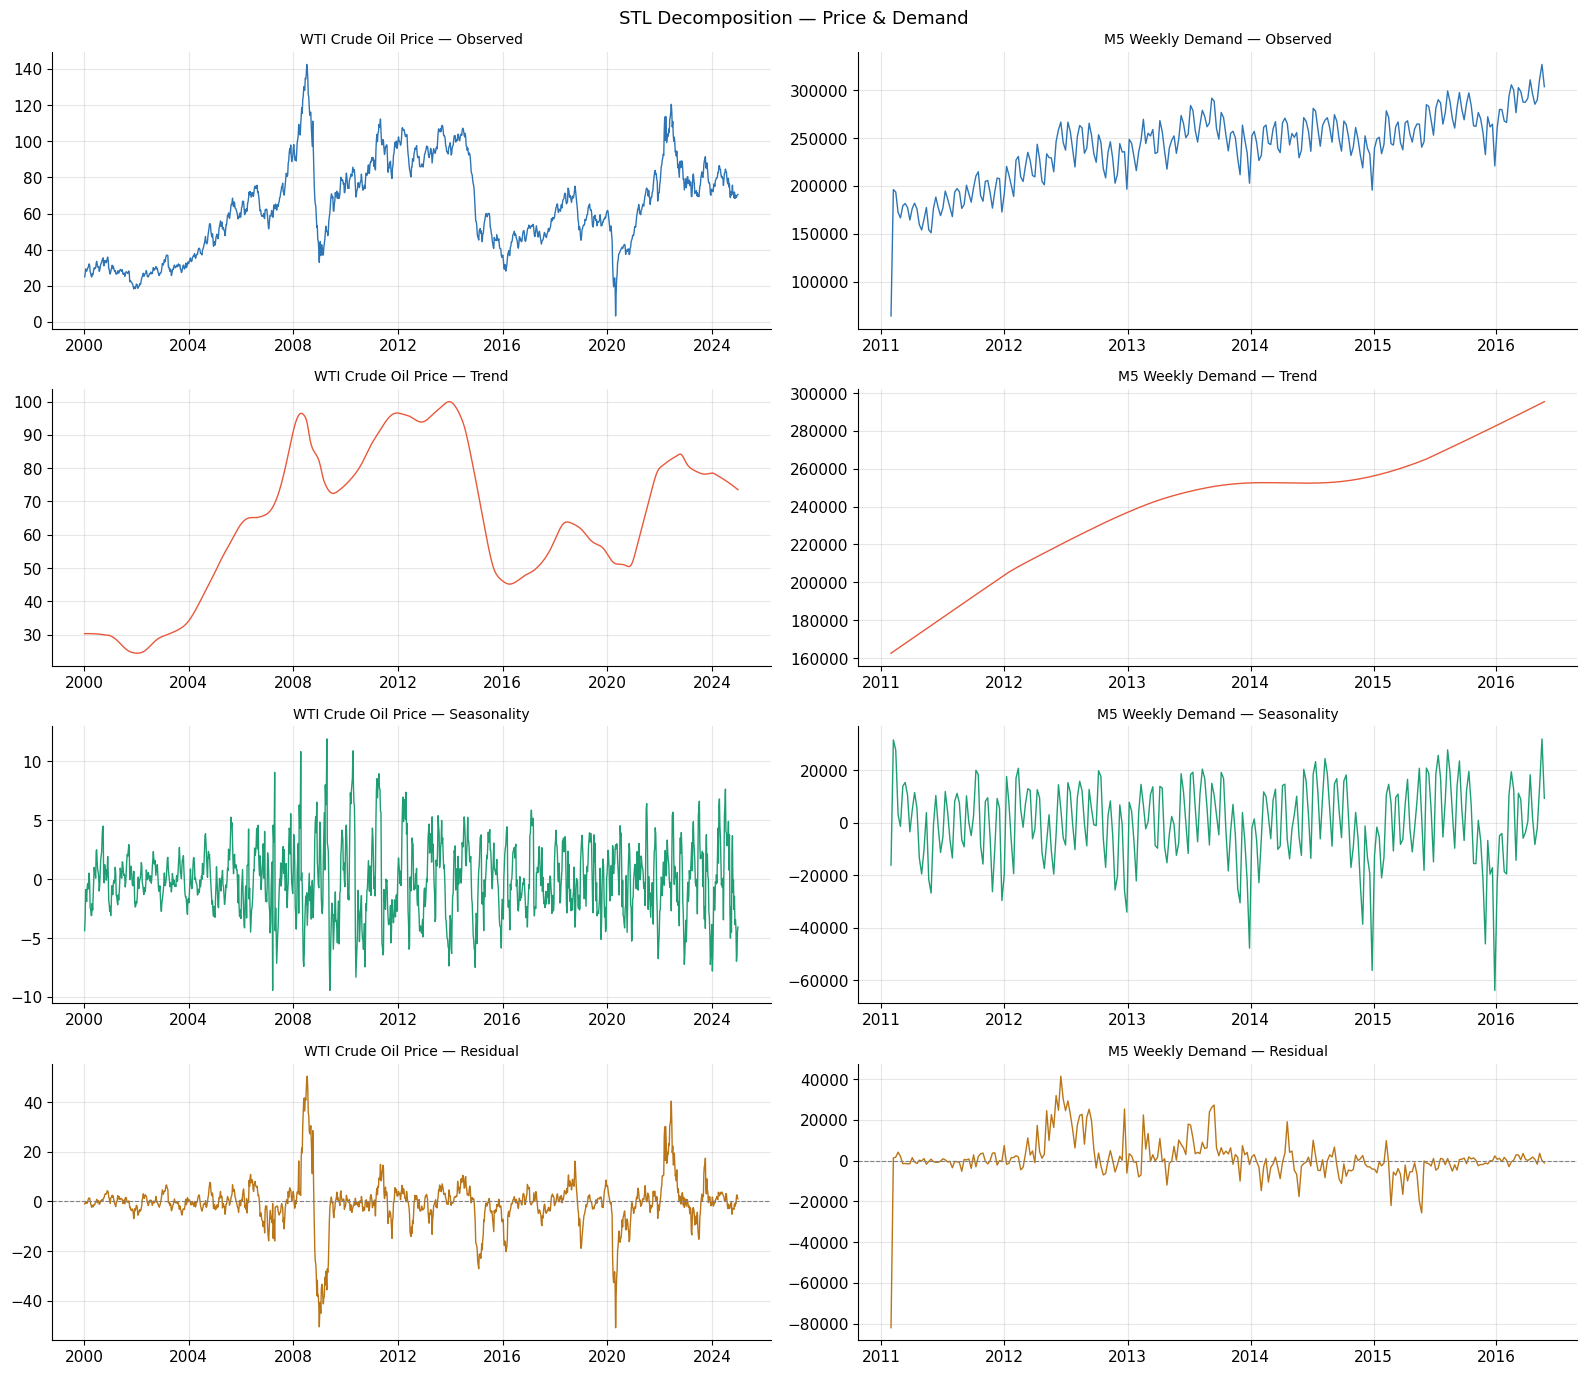

Saved → outputs/figures/04_stl_decomposition.png


In [9]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))

for col_idx, (col, df, title) in enumerate([
    ("crude_oil_wti",  master_df, "WTI Crude Oil Price"),
    ("total_sales",    m5_df,     "M5 Weekly Demand"),
]):
    series = df[col].dropna()

    # STL decomposition — period=52 for weekly data
    stl    = STL(series, period=52, robust=True)
    result = stl.fit()

    components = [
        (series,           "Observed",   COLORS[0]),
        (result.trend,     "Trend",      COLORS[1]),
        (result.seasonal,  "Seasonality",COLORS[2]),
        (result.resid,     "Residual",   COLORS[3]),
    ]

    for row_idx, (component, label, color) in enumerate(components):
        ax = axes[row_idx][col_idx]
        ax.plot(component.index, component.values,
                color=color, linewidth=1.0)
        ax.set_title(f"{title} — {label}", fontsize=10)
        if row_idx == 3:
            ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

plt.suptitle("STL Decomposition — Price & Demand", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/figures/04_stl_decomposition.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/figures/04_stl_decomposition.png")

## 8. Autocorrelation Analysis (ACF / PACF)

ACF and PACF plots tell us how much each series correlates with its
own past values, and at which specific lags. This directly informs
which lag features to create in notebook 03.

**ACF (Autocorrelation Function)**
Shows correlation between the series and its lagged versions.
Significant spikes at lag k mean the value k weeks ago is a useful
predictor. Slow decay indicates non-stationarity (trend present).

**PACF (Partial Autocorrelation Function)**
Shows correlation at lag k after removing the influence of all shorter
lags. PACF spikes indicate the direct relationship at that lag,
independent of intermediate lags. This tells us the minimum set of
lags needed to capture the serial structure.

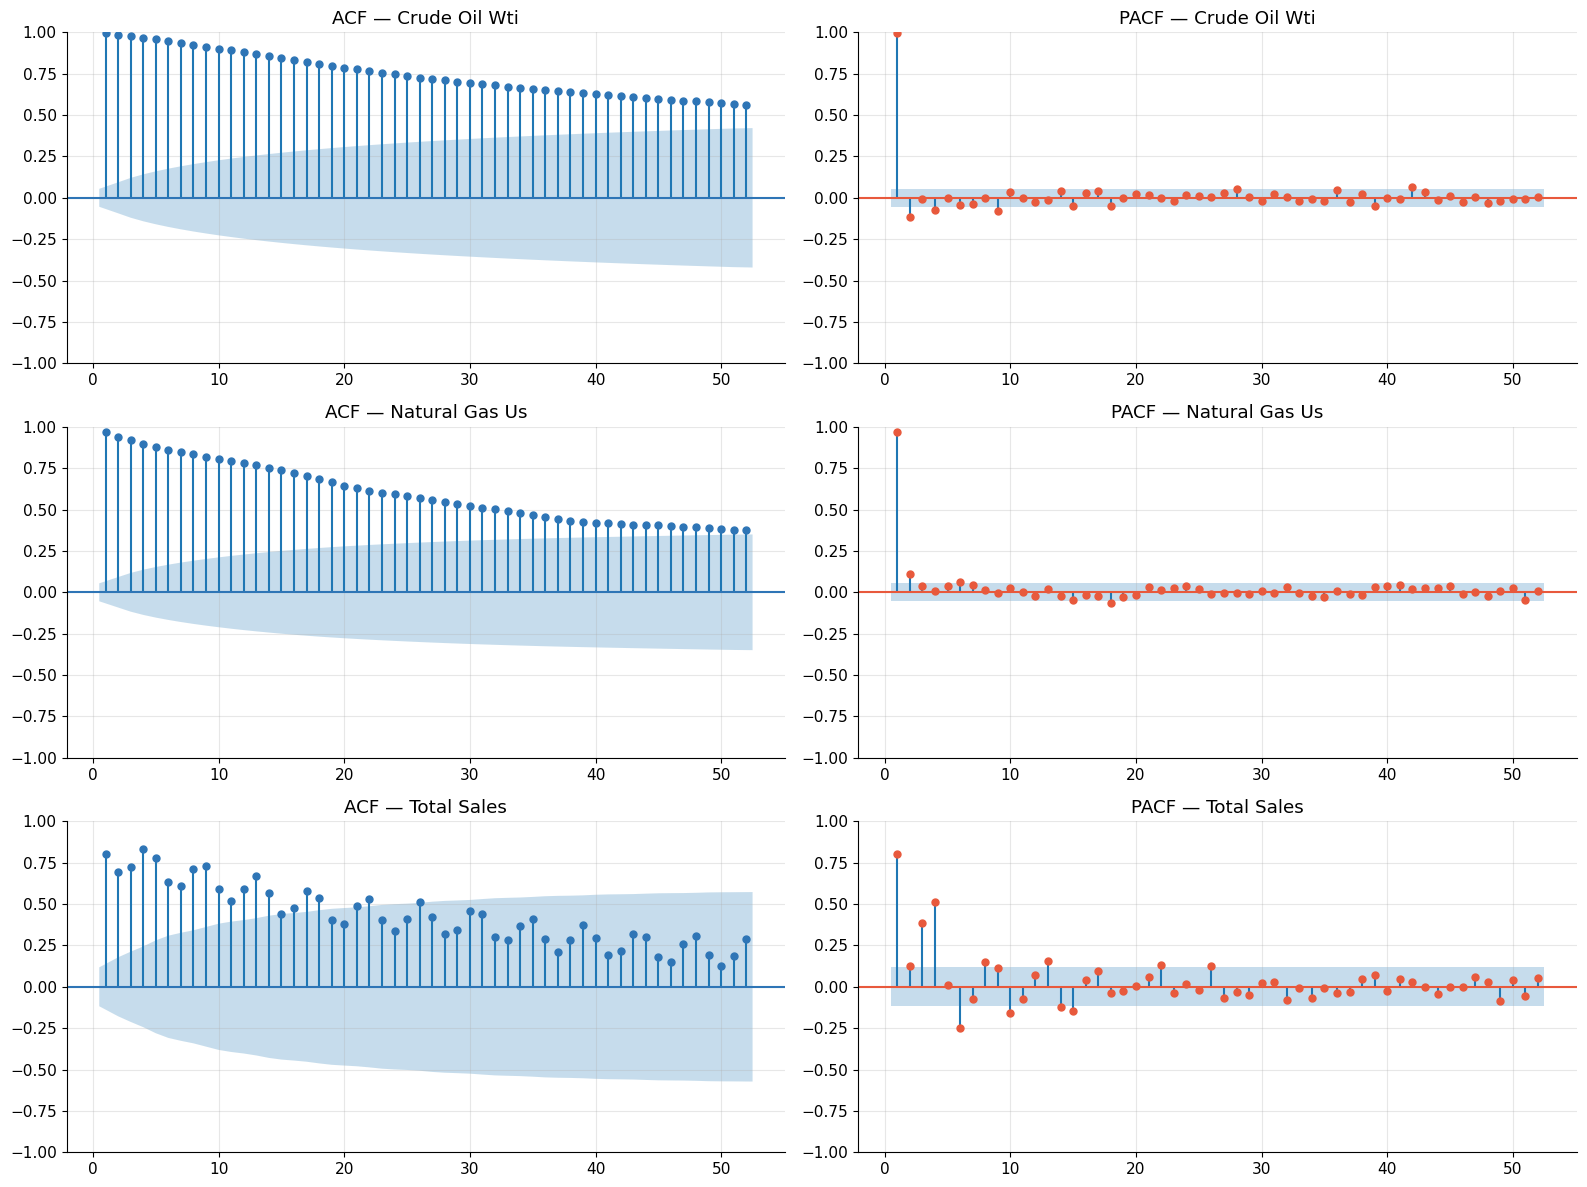

Saved → outputs/figures/05_acf_pacf.png


In [10]:
ACF_SERIES = {
    "crude_oil_wti":   master_df["crude_oil_wti"].dropna(),
    "natural_gas_us":  master_df["natural_gas_henry_hub"].dropna(),
    "total_sales":     m5_df["total_sales"].dropna(),
}

fig, axes = plt.subplots(len(ACF_SERIES), 2,
                         figsize=(16, 4 * len(ACF_SERIES)))

for row, (name, series) in enumerate(ACF_SERIES.items()):
    plot_acf( series, lags=52, ax=axes[row][0],
              title=f"ACF — {name.replace('_',' ').title()}",
              color=COLORS[0], zero=False)
    plot_pacf(series, lags=52, ax=axes[row][1],
              title=f"PACF — {name.replace('_',' ').title()}",
              color=COLORS[1], zero=False, method="ywm")

plt.tight_layout()
plt.savefig("outputs/figures/05_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/figures/05_acf_pacf.png")

## 9. Cross-Correlation Analysis — Leading Indicators

This is the most important section of the EDA notebook.

We compute the **lagged cross-correlation** between each macro/supply
indicator and the two target variables (WTI crude price and M5 demand).
A high correlation at lag k means the indicator leads the target by
k weeks — exactly the kind of predictive signal we want to build into
the feature engineering step.

For example: if crude oil stocks today correlate strongly with WTI
price 4 weeks from now, then crude oil stocks lagged by 4 weeks is a
valuable feature for the price forecasting model.

We test lags from 0 to 26 weeks (6 months).

In [11]:
def lagged_correlations(target, features_df, max_lag=26):
    """
    Compute Pearson correlation between target and each feature
    at lags 0 to max_lag weeks. Returns a DataFrame of shape
    (max_lag+1, n_features).
    """
    results = {}
    target_clean = target.dropna()

    for col in features_df.columns:
        feature = features_df[col].dropna()
        # Align on common index
        aligned = pd.concat([target_clean, feature], axis=1).dropna()
        if len(aligned) < 52:
            continue

        corrs = []
        for lag in range(max_lag + 1):
            if lag == 0:
                corr = aligned.iloc[:, 0].corr(aligned.iloc[:, 1])
            else:
                corr = aligned.iloc[lag:, 0].corr(aligned.iloc[:-lag, 1])
            corrs.append(round(corr, 3))
        results[col] = corrs

    return pd.DataFrame(results, index=range(max_lag + 1))


FEATURE_COLS = [c for c in master_df.columns
                if c not in ["crude_oil_wti", "natural_gas_henry_hub"]]

# Cross-correlations for WTI crude oil price
corr_price  = lagged_correlations(
    master_df["crude_oil_wti"],
    master_df[FEATURE_COLS]
)

# Cross-correlations for M5 demand
# Align M5 dates with master_df
m5_aligned = m5_df["total_sales"].reindex(master_df.index)
corr_demand = lagged_correlations(
    m5_aligned,
    master_df[FEATURE_COLS]
)

print("Top leading indicators for WTI Crude Oil Price")
print("(sorted by maximum absolute correlation across all lags)\n")
top_price = (
    corr_price.abs().max()
    .sort_values(ascending=False)
    .head(10)
)
for feat, max_corr in top_price.items():
    best_lag = corr_price[feat].abs().idxmax()
    print(f"  {feat:<35} max |r| = {max_corr:.3f}  at lag {best_lag:>2} weeks")

print("\nTop leading indicators for M5 Demand")
print("(sorted by maximum absolute correlation across all lags)\n")
top_demand = (
    corr_demand.abs().max()
    .sort_values(ascending=False)
    .head(10)
)
for feat, max_corr in top_demand.items():
    best_lag = corr_demand[feat].abs().idxmax()
    print(f"  {feat:<35} max |r| = {max_corr:.3f}  at lag {best_lag:>2} weeks")

Top leading indicators for WTI Crude Oil Price
(sorted by maximum absolute correlation across all lags)

  crude_oil_avg                       max |r| = 0.963  at lag  0 weeks
  fertiliser_urea                     max |r| = 0.740  at lag  0 weeks
  coal_australia                      max |r| = 0.548  at lag  0 weeks
  ppi_chemicals                       max |r| = 0.500  at lag  0 weeks
  ppi_plastics                        max |r| = 0.498  at lag  0 weeks
  industrial_production_idx           max |r| = 0.473  at lag  0 weeks
  phosphate_rock                      max |r| = 0.463  at lag  0 weeks
  us_gdp                              max |r| = 0.398  at lag 26 weeks
  natural_gas_us                      max |r| = 0.297  at lag 26 weeks
  capacity_utilisation                max |r| = 0.275  at lag 16 weeks

Top leading indicators for M5 Demand
(sorted by maximum absolute correlation across all lags)

  coal_australia                      max |r| = 0.847  at lag  1 weeks
  unemployment_rat

## 10. Cross-Correlation Heatmap

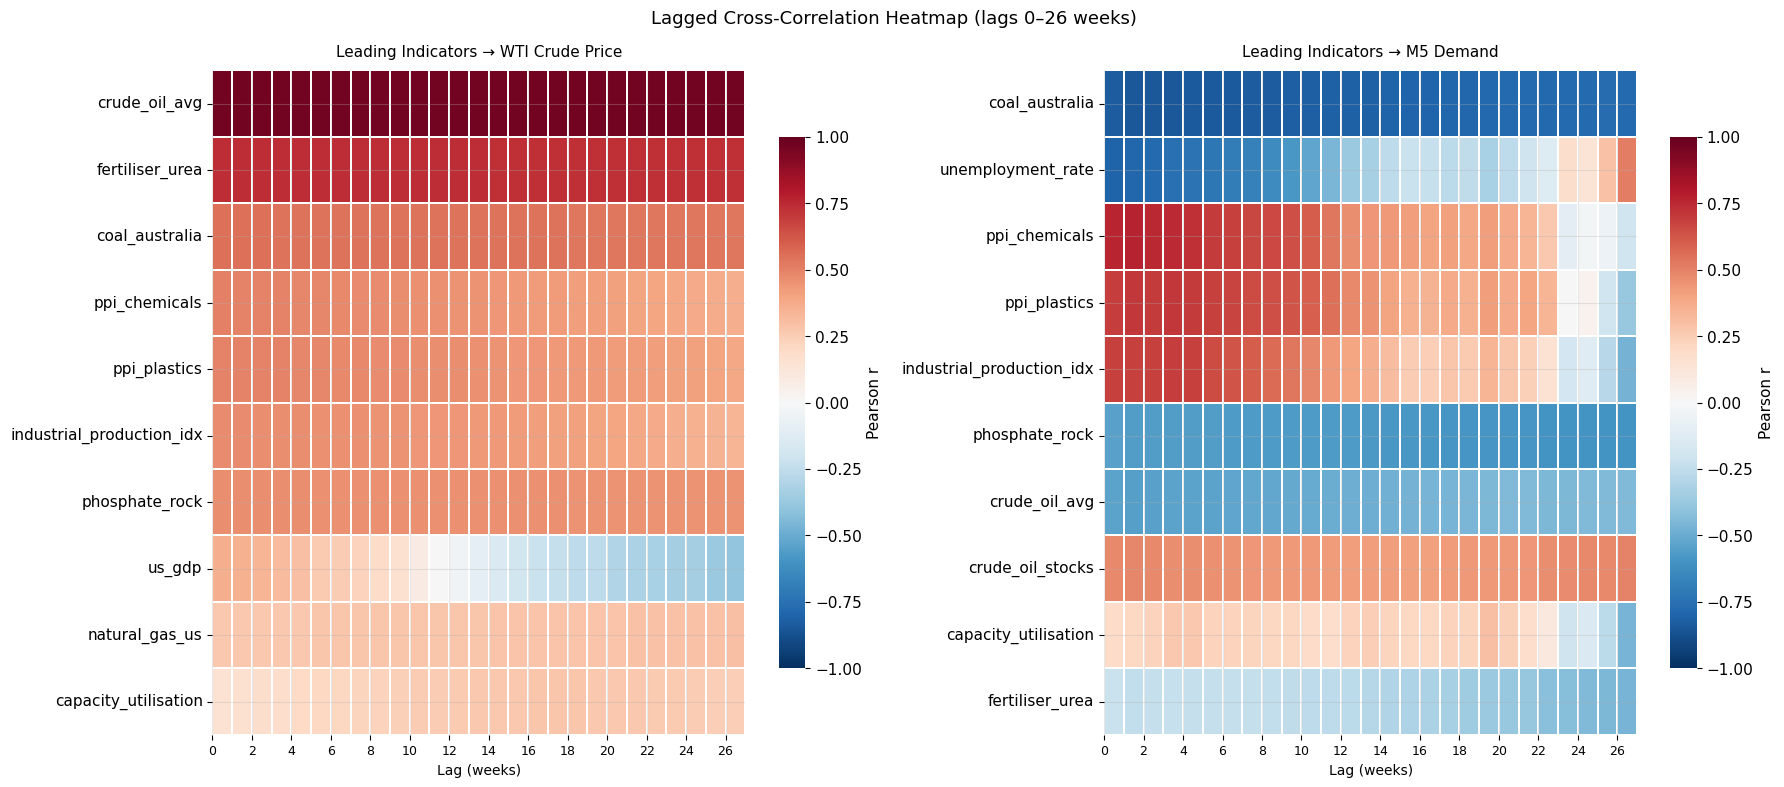

Saved → outputs/figures/06_crosscorr_heatmap.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, corr_df, title in [
    (axes[0], corr_price,  "Leading Indicators → WTI Crude Price"),
    (axes[1], corr_demand, "Leading Indicators → M5 Demand"),
]:
    # Keep top 10 features by max absolute correlation
    top_cols = corr_df.abs().max().sort_values(ascending=False).head(10).index
    plot_df  = corr_df[top_cols].T   # features as rows, lags as columns

    sns.heatmap(
        plot_df,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        vmin=-1, vmax=1,
        annot=False,
        linewidths=0.3,
        cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    )
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel("Lag (weeks)", fontsize=10)
    ax.set_ylabel("")

    # Set ticks explicitly to match label count
    tick_positions = list(range(0, 27, 2))
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(
        [str(x) for x in tick_positions],
        rotation=0, fontsize=9
    )

plt.suptitle("Lagged Cross-Correlation Heatmap (lags 0–26 weeks)",
             fontsize=13)
plt.tight_layout()
plt.savefig("outputs/figures/06_crosscorr_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/figures/06_crosscorr_heatmap.png")

## 11. Data Quality Summary

A systematic audit of missing values across all series.
Understanding the missingness pattern is important — random gaps
can be forward-filled, but systematic gaps (e.g. a series that
only starts in 2007) need to be noted and handled explicitly in
feature engineering.

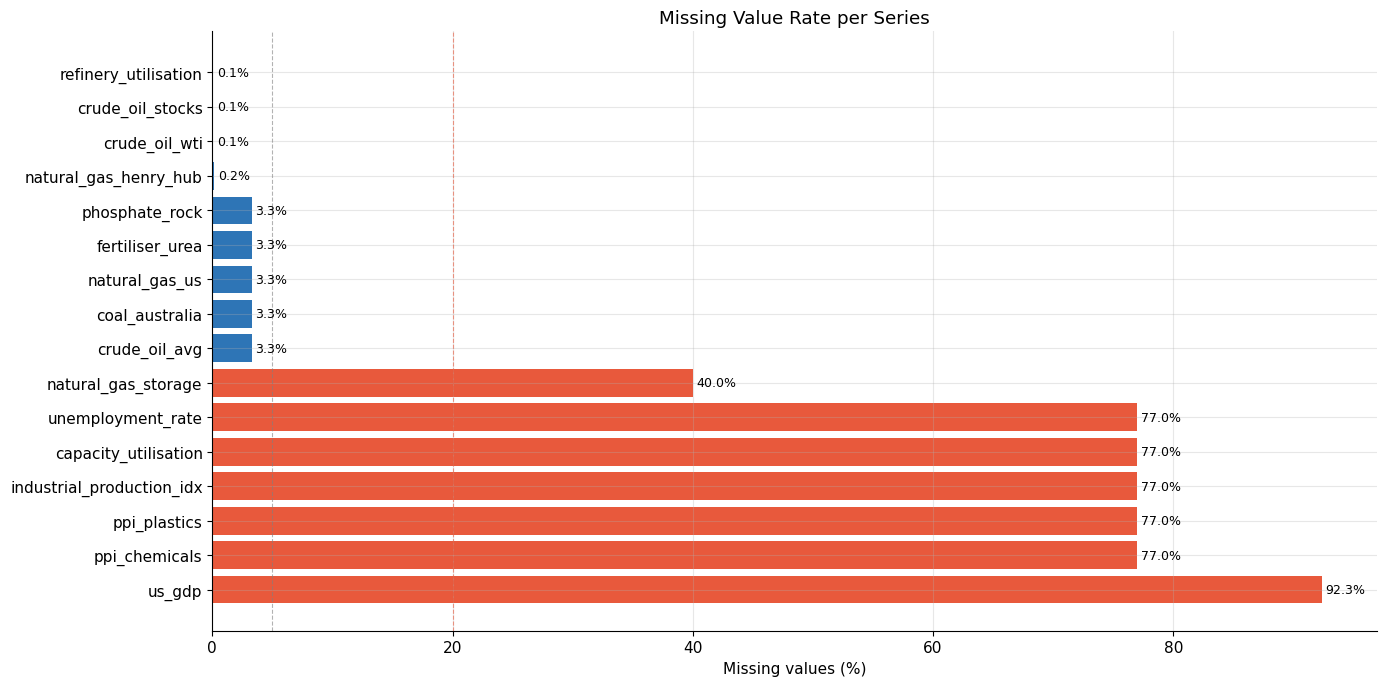


Missingness summary:
  Series with < 5% missing  : 9 — safe to forward-fill
  Series with 5–20% missing : 0 — forward-fill with caution
  Series with > 20% missing : 7 — note start date, fill carefully


In [14]:
fig, ax = plt.subplots(figsize=(14, 7))

# Build missingness matrix
miss_pct = (master_df.isna().mean() * 100).sort_values(ascending=False)

bars = ax.barh(miss_pct.index, miss_pct.values,
               color=[COLORS[1] if v > 20 else COLORS[0]
                      for v in miss_pct.values])

ax.axvline(5,  color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axvline(20, color=COLORS[1], linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlabel("Missing values (%)")
ax.set_title("Missing Value Rate per Series")

for bar, val in zip(bars, miss_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/figures/07_missing_values.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nMissingness summary:")
print(f"  Series with < 5% missing  : "
      f"{(miss_pct < 5).sum()} — safe to forward-fill")
print(f"  Series with 5–20% missing : "
      f"{((miss_pct >= 5) & (miss_pct < 20)).sum()} — forward-fill with caution")
print(f"  Series with > 20% missing : "
      f"{(miss_pct >= 20).sum()} — note start date, fill carefully")

In [ ]:
## 12. EDA Summary & Feature Engineering Decisions

Based on the analysis above, we document the key findings and the
decisions they drive in notebook 03.

This section is written as a reference — update the findings after
running the cells above and seeing the actual results.

In [17]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                        EDA FINDINGS SUMMARY                                  ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. STATIONARITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
All price series (WTI crude, natural gas, coal, fertiliser, phosphate) are
NON-STATIONARY. ACF plots confirm this — autocorrelation decays very slowly
across all 52 lags without crossing the confidence band, a classic signature
of a unit-root process driven by trend rather than mean-reversion.

PACF plots show a sharp cutoff after lag 1–2 for both crude oil and natural
gas, meaning once the immediate memory is accounted for there is little
additional direct autocorrelation. This is consistent with a random walk
with drift — prices are best predicted by their most recent values plus
external macro drivers.

M5 demand shows faster ACF decay (reaches ~0.25 by lag 52) and a richer
PACF structure with significant spikes at lags 1, 2, 3 and a negative spike
around lag 4, suggesting a more complex AR structure with seasonal reversal.

→ Implication for modelling:
  - LightGBM: handles non-stationarity natively via lag features
  - Prophet: will capture trend component automatically
  - SARIMA: requires first differencing (d=1) before fitting
  - Log transformation recommended for price targets to stabilise variance

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. SEASONALITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WTI crude oil seasonality is WEAK and irregular (STL seasonal component
±10 vs trend range of 20–140). The seasonal signal is noisy and inconsistent
year-to-year, meaning supply shocks and geopolitical events dominate over
any calendar pattern. Four major structural breaks are clearly visible:
GFC 2008–09, oil price crash 2014–16, COVID demand shock 2020, and the
2021–22 commodity supercycle driven by post-COVID recovery and Ukraine war.

M5 demand seasonality is STRONG and highly structured (STL seasonal
component ±60,000 units on a base of ~250,000 — roughly ±24% amplitude).
The year-over-year overlay confirms a consistent pattern: demand dips in
early spring (weeks 10–15), recovers through summer, and peaks sharply
in weeks 48–52 (Thanksgiving and Christmas effect). The 2011 ramp-up
from ~64k to ~200k units reflects new store openings, not seasonality.

Natural gas storage shows the strongest and most consistent seasonality
of all series — the clear injection/withdrawal cycle is visible in the
macro chart with a period of exactly 52 weeks.

→ Implication for modelling:
  - Seasonal period = 52 weeks for all models
  - M5 demand benefits most from explicit calendar features
  - Crude oil models should include structural break indicators
  - Natural gas models should weight seasonal features heavily

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. LEADING INDICATORS (cross-correlation findings)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FOR WTI CRUDE PRICE:
  crude_oil_avg and fertiliser_urea show the strongest positive correlation
  (r > 0.90) that remains stable across all lags 0–26, confirming these
  are co-moving commodity markets rather than leading indicators per se.
  coal_australia, ppi_chemicals, and ppi_plastics also correlate strongly
  (r ~ 0.60–0.75) and maintain correlation at longer lags, suggesting
  broad commodity cycle co-movement. us_gdp shifts from positive to mildly
  negative correlation beyond lag 12, reflecting the lagged demand
  destruction effect of high energy prices on economic output.
  capacity_utilisation and natural_gas_us show weaker, flatter correlation
  across all lags.

FOR M5 DEMAND:
  coal_australia and unemployment_rate show strong NEGATIVE correlation
  (deep blue, r ~ -0.70 to -0.85) — higher commodity prices and higher
  unemployment both suppress consumer demand, as expected economically.
  ppi_chemicals and ppi_plastics show strong POSITIVE correlation
  (r ~ 0.60–0.75) — these rise together with general economic expansion
  which also drives consumer spending. industrial_production_idx shows
  positive correlation that weakens gradually with lag. phosphate_rock,
  crude_oil_avg, and crude_oil_stocks show mild negative correlation —
  high input costs reduce disposable income and consumer demand.

→ Implication for feature engineering:
  Price model   : include crude_oil_avg (lag 2–4), fertiliser_urea (lag 4),
                  coal_australia (lag 4), ppi_chemicals (lag 4–6)
  Demand model  : include unemployment_rate (lag 2–4), ppi_chemicals (lag 2),
                  ppi_plastics (lag 2), industrial_production_idx (lag 4–6)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. DATA QUALITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  refinery_utilisation   0.1%  → negligible, safe to forward-fill
  crude_oil_stocks       0.1%  → negligible, safe to forward-fill
  crude_oil_wti          0.1%  → negligible, safe to forward-fill
  natural_gas_henry_hub  0.2%  → negligible, safe to forward-fill
  phosphate_rock         3.3%  → World Bank series starts Oct 2000, forward-fill
  fertiliser_urea        3.3%  → World Bank series starts Oct 2000, forward-fill
  natural_gas_us         3.3%  → World Bank series starts Oct 2000, forward-fill
  coal_australia         3.3%  → World Bank series starts Oct 2000, forward-fill
  crude_oil_avg          3.3%  → World Bank series starts Oct 2000, forward-fill
  natural_gas_storage   40.0%  → EIA series starts 2007, forward-fill from start
  unemployment_rate     77.0%  → monthly FRED series, forward-fill (valid approach)
  capacity_utilisation  77.0%  → monthly FRED series, forward-fill
  industrial_prod_idx   77.0%  → monthly FRED series, forward-fill
  ppi_plastics          77.0%  → monthly FRED series, forward-fill
  ppi_chemicals         77.0%  → monthly FRED series, forward-fill
  us_gdp                92.3%  → quarterly FRED series, forward-fill

→ Implication for feature engineering:
  Forward-fill (ffill) all monthly and quarterly series — this is the
  correct handling for macro releases where the last known value remains
  valid until the next release date. Do NOT interpolate macro series as
  this would introduce future information into past periods (data leakage).
  natural_gas_storage features will only be valid from 2007 onward —
  models trained on the full 2000–2024 window should treat pre-2007
  natural gas storage values as missing and handle accordingly.
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                        EDA FINDINGS SUMMARY                                  ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. STATIONARITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
All price series (WTI crude, natural gas, coal, fertiliser, phosphate) are
NON-STATIONARY. ACF plots confirm this — autocorrelation decays very slowly
across all 52 lags without crossing the confidence band, a classic signature
of a unit-root process driven by trend rather than mean-reversion.

PACF plots show a sharp cutoff after lag 1–2 for both crude oil and natural
gas, meaning once the immediate memory is accounted for there is little
additional direct autocorrelation. This is consistent with a random walk
with drift — prices are best predicted by their most recent values p

## Notebook 02 Complete

All EDA sections finished. Outputs saved:

| Section | Output file |
|---|---|
| Price series visualisation | `outputs/figures/01_price_series.png` |
| Macro & supply indicators | `outputs/figures/02_macro_series.png` |
| M5 demand inspection | `outputs/figures/03_m5_demand.png` |
| STL decomposition | `outputs/figures/04_stl_decomposition.png` |
| ACF / PACF analysis | `outputs/figures/05_acf_pacf.png` |
| Cross-correlation heatmap | `outputs/figures/06_crosscorr_heatmap.png` |
| Missing value audit | `outputs/figures/07_missing_values.png` |
| Stationarity test results | `outputs/reports/stationarity_tests.csv` |

### Key decisions carried forward to `03_features.ipynb`

**Lag features:** 1, 2, 4, 8, 12, 26 weeks
(informed by PACF cutoffs and cross-correlation peaks)

**Rolling windows:** 4, 8, 12, 26 weeks — mean, std, min, max

**Exogenous features for price model:**
crude_oil_avg (lag 2–4), fertiliser_urea (lag 4),
coal_australia (lag 4), ppi_chemicals (lag 4–6)

**Exogenous features for demand model:**
unemployment_rate (lag 2–4), ppi_chemicals (lag 2),
ppi_plastics (lag 2), industrial_production_idx (lag 4–6)

**Missing value strategy:** forward-fill all monthly/quarterly series —
no interpolation to avoid data leakage into past periods

**Transformation:** log(price) for all non-stationary price targets

**Seasonal period:** 52 weeks for all models

**Next → `03_features.ipynb`**